In [1]:
# Работа с данными
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import randint, uniform, loguniform

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Машинное обучение
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import LearningCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score)
from sklearn.model_selection import (train_test_split, RandomizedSearchCV)  
import shap

In [2]:
# Пользовательские настройки

pd.set_option("display.max_columns", None)  # макс. отображаемые колонки - неограничено
sns.set_theme(style="whitegrid")  # стиль графиков - whitegrid

Загрузим исходные данные в рабочую среду. Наши данные находятся в файле data.csv

In [3]:
df = pd.read_csv("data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


# Подготовка данных <a name="dataprep"></a>

Сначала подготовим данные для анализа. Посмотрим на:
- Типы данных.
- Названия столбцов.
- Пустые значения.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

Первое, что замечаем:
- Пустые значения и лишние символы в столбце дохода (Income)
- Названия стран (Country) представлены аббревиатурами
- Неподходящий формат столбцов Income и Dt_Customer
- Лишние символы в названия столбцов

In [5]:
# Аббревиатура страны и ее полное название

country_abbreviations = {
        "SP": "Spain",
        "US": "United States",
        "CA": "Canada",
        "AUS": "Australia",
        "GER": "Germany",
        "IND": "India",
        "SA": "South Africa",
        "ME": "Mexico"
    }

In [6]:
# Очищаем названия стобцов от пробелов
df.columns = df.columns.str.strip()

# Убираем лишние символы из колонки Income
df["Income"] = df["Income"].str.replace("$", "").str.replace(",", "").astype("float")

# Приводим столбец Dt_Customer к типу datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y")

# Заменяем аббревиатуры стран на их полные названия
df["Country"] = df["Country"].map(country_abbreviations)

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,United States
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,Spain


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

# 1. Разведочный анализ (EDA)

Прежде чем делать какие-либо выводы, мы должны провести разведочный анализ имеющихся данных. Цель: 
- Обработка пустых значений
- Обнаружение выбросов
- Создание новых признаков на основе имеющихся (дата инжиниринг)
- Обнаружение полезных взаимосвязей, а также аномалий

## 1.1. Пустые значения и выбросы

Ранее мы обнаружили, что в Income есть пустые значения.

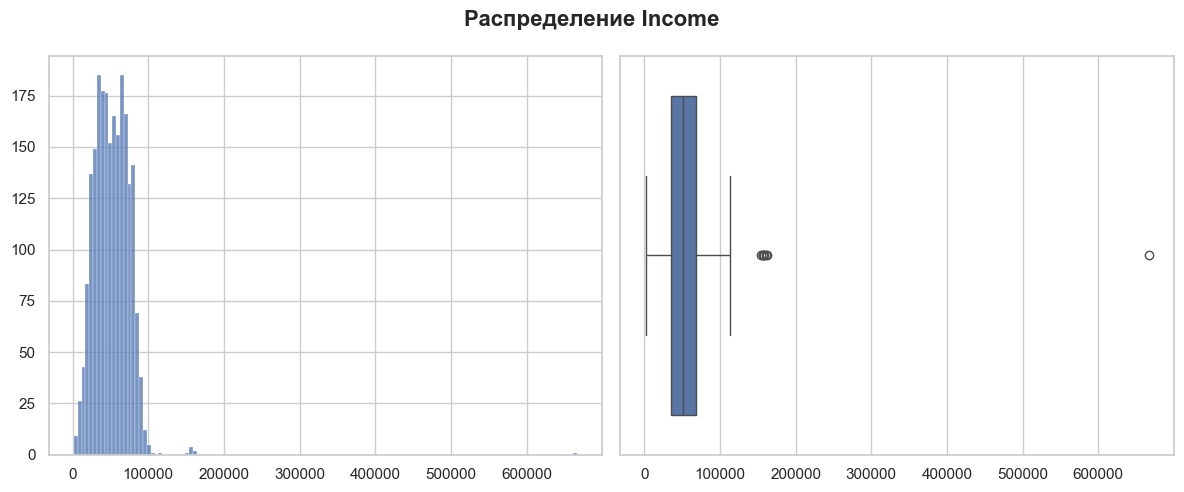

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Гистограмма распределения Income
sns.histplot(df, x="Income", ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("")

# График box-plot Income
sns.boxplot(df, x="Income", ax=ax[1])
ax[1].set_xlabel("")
ax[1].set_ylabel("")

fig.suptitle("Распределение Income", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

Основная часть Income имеет распределение близкое к нормальному.\
Используя метод импутации, заполним пустые значения медианой.

In [10]:
df.fillna({"Income": df["Income"].median()}, inplace=True)
print("Наличие пустых значений:", df["Income"].isna().any(), sep=" ")

Наличие пустых значений: False


Также, посмотрим на краткую статистику количественных переменных.

In [11]:
df.describe(include=np.number)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Сразу обратим внимание на следующее:
- В столбце Income присутствуют значительные отклонения (>600,000).
- В столбце Year_Birth также имеются отклонения (<1920).

Вероятнее всего, такие значения указывают на ошибку ввода данных.\
Сделаем фильтрацию датасета, оставив только записи с Year_Birth >= 1920 и Income < 200,000.\
Это не скажется на результатах последующего анализа.

In [12]:
df = df[(df["Income"] < 200_000) & (df["Year_Birth"] >= 1920)].reset_index(drop=True)

Оценим конечное распределение Income и Year_Birth.

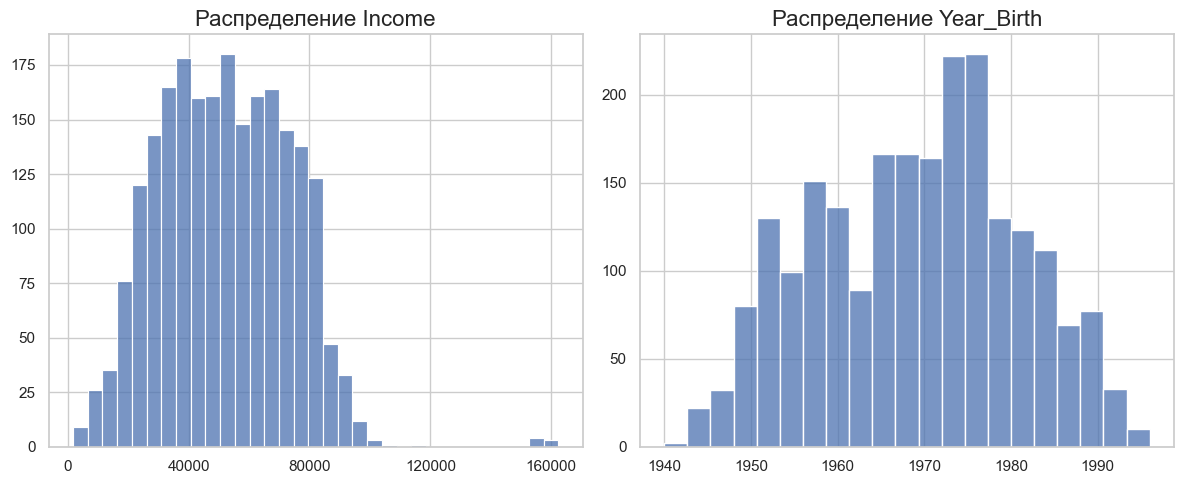

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма распределения Income
sns.histplot(df, x="Income", ax=ax[0])
ax[0].set_xticks(np.arange(0, 180000, 40000))
ax[0].set_title("Распределение Income", fontsize=16)
ax[0].set_xlabel("")
ax[0].set_ylabel("")

# Гистограмма распределения Year_Birth
sns.histplot(df.Year_Birth, ax=ax[1])
ax[1].set_title("Распределение Year_Birth", fontsize=16)
ax[1].set_xlabel("")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 1.2. Дата инжиниринг

Список признаков, которые можно создать на основе имеющихся:
- Общее число детей у клиента (Dependents)
- Год первого взаимодействия с компанией (Year_Customer)
- Общая сумма покупок (TotalMnt)
- Количество купленных товаров (TotalPurchases)
- Количество кампаний, в которых клиент принял участие (TotalAcceptedCmp)

In [14]:
# Dependents вычисляется как сумма столбцов Kidhome и Teenhome
df["Dependents"] = df["Kidhome"] + df["Teenhome"]

# Год первого взаимодействия (Year_Customer)
df["Year_Customer"] = df["Dt_Customer"].dt.year
df.drop(["Dt_Customer"], axis=1, inplace=True)

# Общая сумма покупок (TotalMnt)
mnt_cols = [col for col in df.columns if col.startswith("Mnt")]
df["TotalMnt"] = df[mnt_cols].sum(axis=1)

# Общее количество купленных товаров (TotalPurchases)
purchase_cols = [col for col in df.columns if col.endswith("Purchases")]
df["TotalPurchases"] = df[purchase_cols].sum(axis=1)

# Количество участий в кампаниях (TotalAcceptedCmp)
campaign_cols = [col for col in df.columns if col.startswith("AcceptedCmp") or col == "Response"]
df["TotalAcceptedCmp"] = df[campaign_cols].sum(axis=1)

# Отобразим получившиеся признаки
df[['ID', 'Dependents', 'Year_Customer', 'TotalMnt', 'TotalPurchases', 'TotalAcceptedCmp']].head()

,ID,Dependents,Year_Customer,TotalMnt,TotalPurchases,TotalAcceptedCmp
0,1826,0,2014,1190,15,1
1,1,0,2014,577,18,2
2,10476,1,2014,251,11,0
3,1386,2,2014,11,4,0
4,5371,1,2014,91,8,2


## 1.3. Зависимости/аномалии в данных

Для обнаружения возможных зависимостей построим корреляционную таблицу и визуализируем полученный результат на тепловой карте.

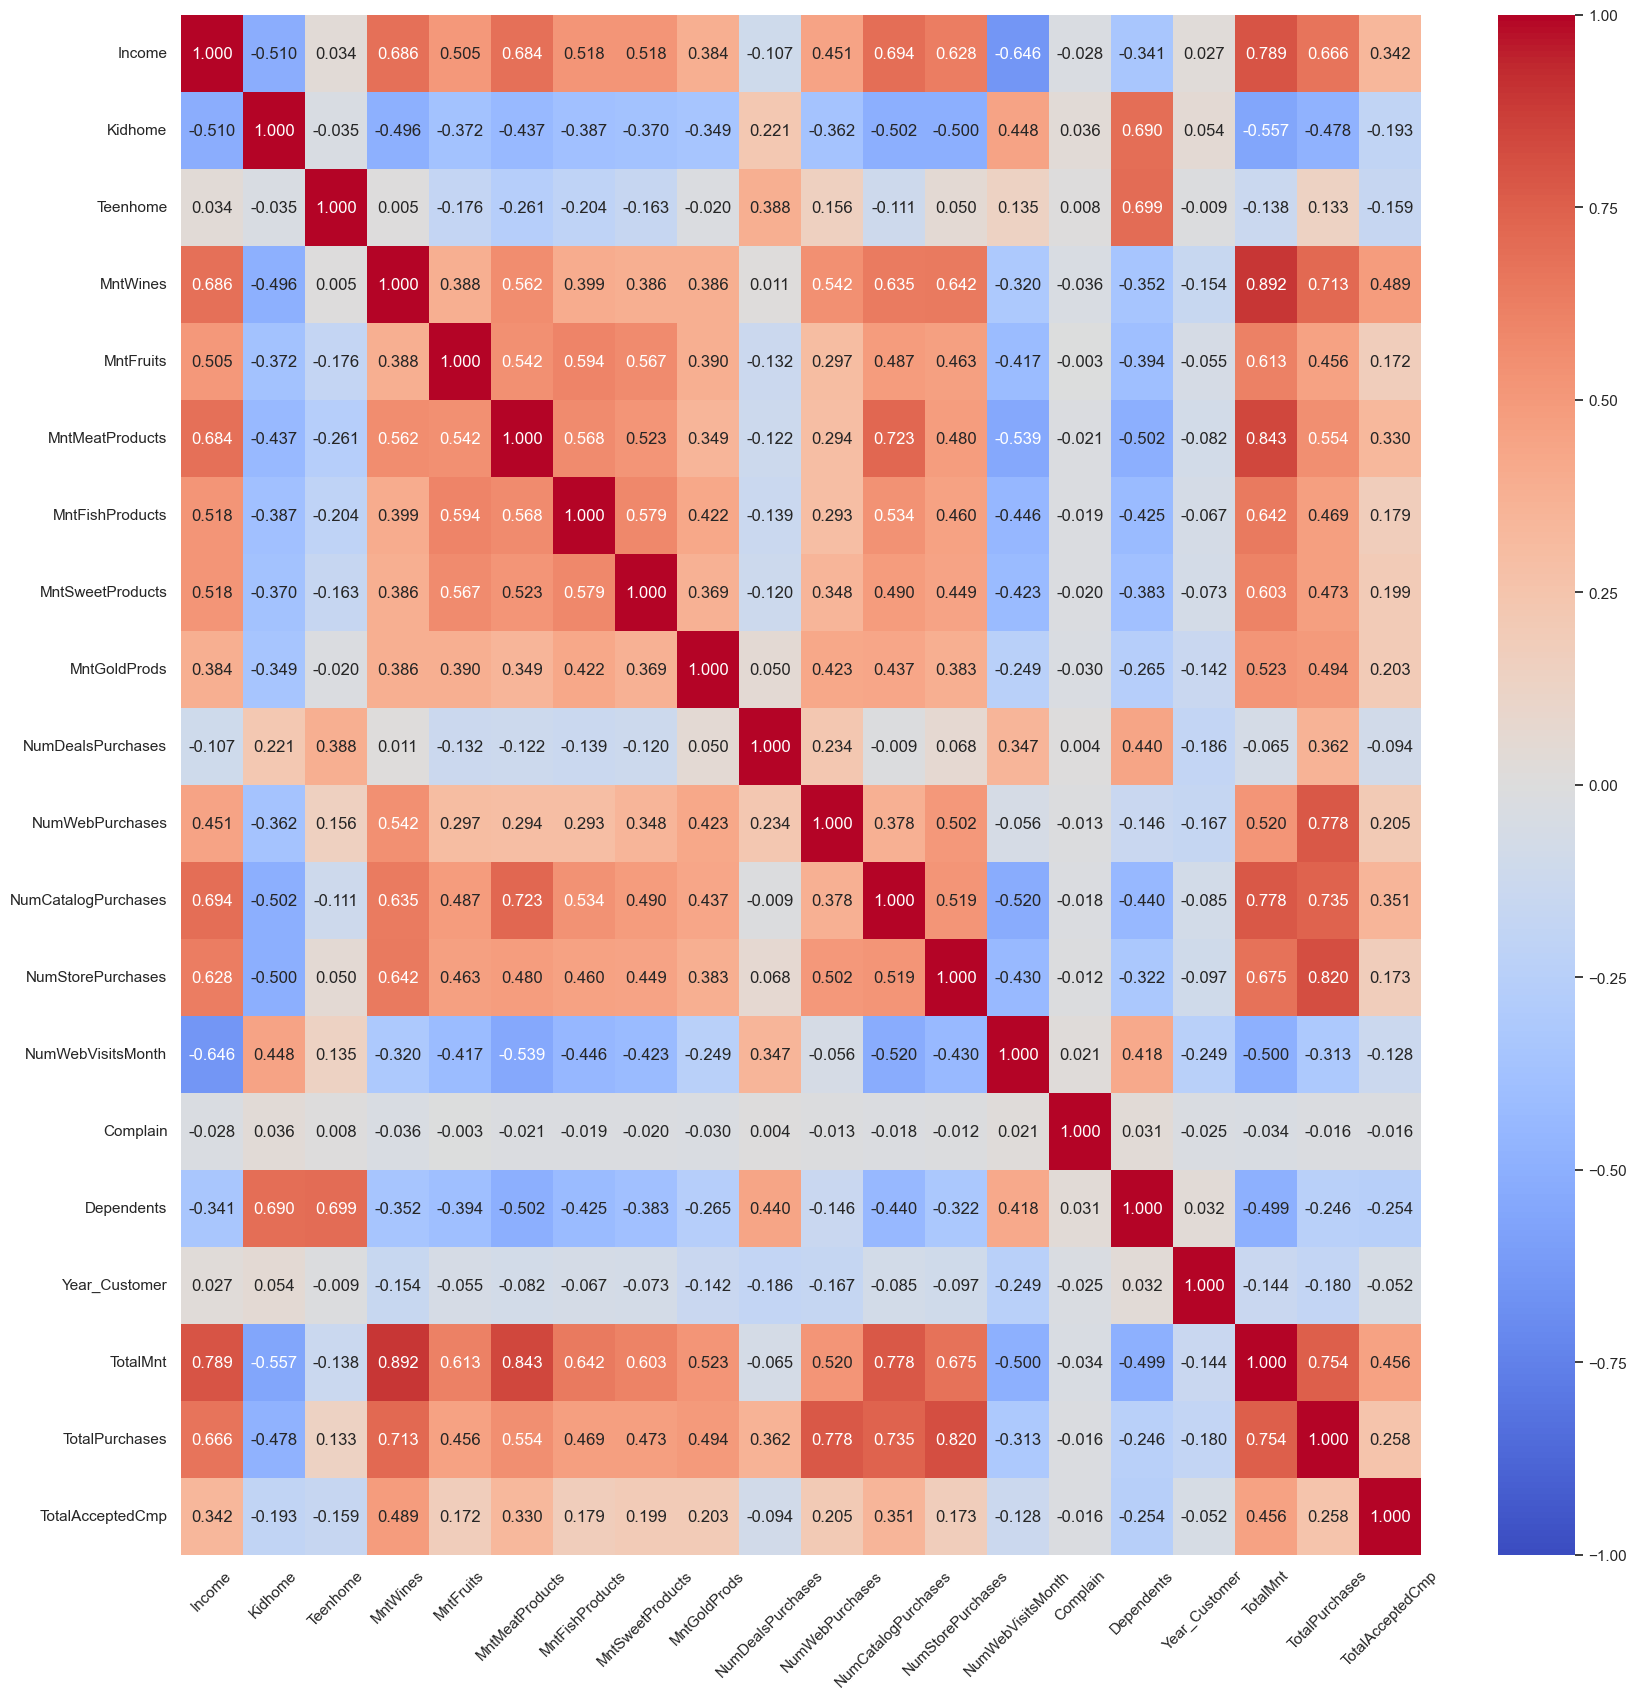

In [15]:
# Исключим из данных лишние столбцы (идентификатор клиента, год рождения и т.д.)
corr_df = df.drop(["ID", "Year_Birth", "Education", "Marital_Status", "Country", "Recency"] + campaign_cols, axis=1).corr()

plt.figure(figsize=(20, 20))

# Тепловая карта
sns.heatmap(
    corr_df,
    cmap=plt.cm.coolwarm,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".3f",
)

plt.xticks(rotation=45)
plt.show()

Сразу выделим наиболее интересные взаимосвязи/аномалии:
1. Уровень дохода (Income) и сумма покупок (TotalMnt) -> **Средняя положительная корреляция (0.789)**\
   **Вывод**: *клиенты с более высоким доходом потратят в магазине больше*
2. Количество покупок по скидке (NumDealsPurchases) и число детей у клиента (Dependents) -> **Средняя положительная корреляция (0.440)**\
   **Вывод**: *клиенты с детьми в среднем будут тратить меньше*
3. Уровень дохода (Income) и суммарное участие в кампаниях (TotalAcceptedCmp) -> **Средняя положительная корреляция (0.342)**
4. Сумма покупок (TotalMnt) и количество детей (Dependents) -> **Средняя отрицательная корреляция (-0.499)**\
   **Вывод**: *логично выходит из (2)*

Также стоит обратить внимание на следующее:
- Посещение интернет-магазина за последний месяц (NumWebVisitsMonth) и количество онлайн-покупок (NumWebPurchases) -> **Корреляция отсутствует (~0)**\
  **Вывод**: интернет-магазин не привлекает клиентов: проблемы с сайтом: дизайн, ассортимент, путь от заказа до покупки и т.д.
- NumWebVisitsMonth отрицательно коррелирует со всеми другими видами покупок, кроме покупок по скидке (NumDealsPurchases)\
  **Вывод**: отсутствуют скиди в интернет-магазине, а соответственно, нет влияния со стороны NumWebVisitsMonth

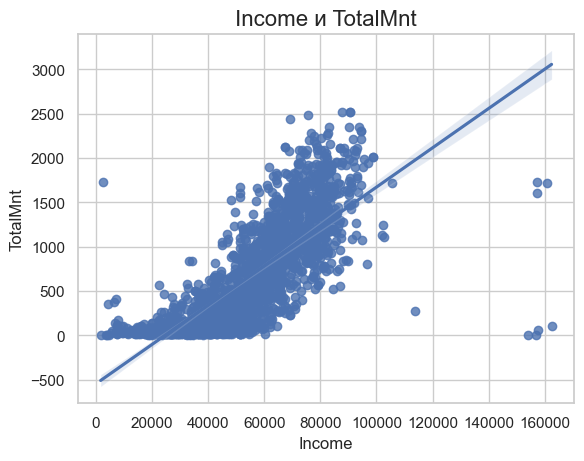

In [16]:
sns.regplot(data=df, x="Income", y="TotalMnt")
plt.title("Income и TotalMnt", size=16)
plt.show()

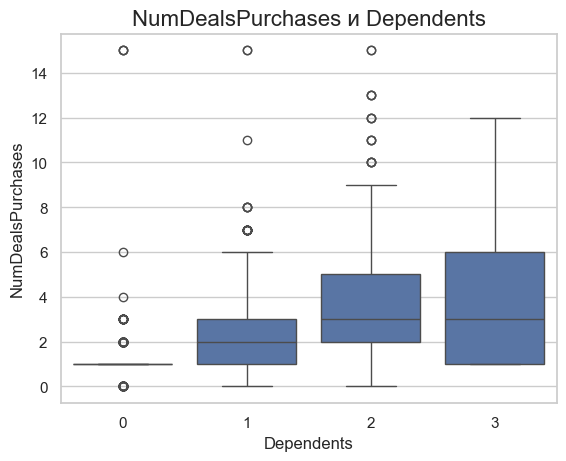

In [17]:
sns.boxplot(data=df, x="Dependents", y="NumDealsPurchases")
plt.title("NumDealsPurchases и Dependents", size=16)
plt.show()

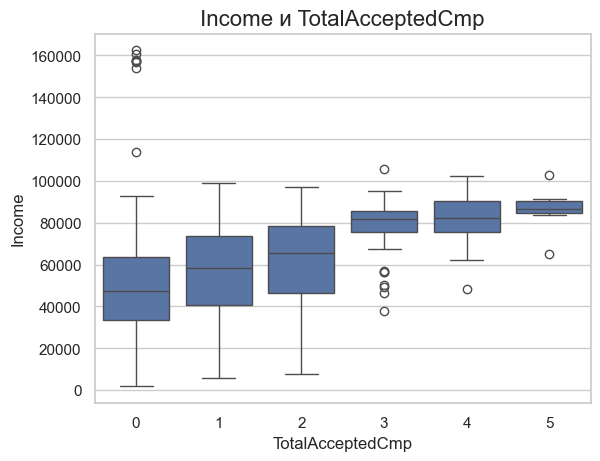

In [18]:
sns.boxplot(data=df, x="TotalAcceptedCmp", y="Income")
plt.title("Income и TotalAcceptedCmp", size=16)
plt.show()

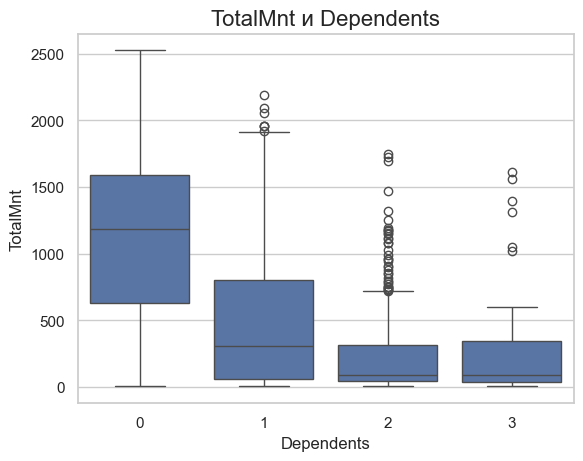

In [19]:
sns.boxplot(data=df, x="Dependents", y="TotalMnt")
plt.title("TotalMnt и Dependents", size=16)
plt.show()

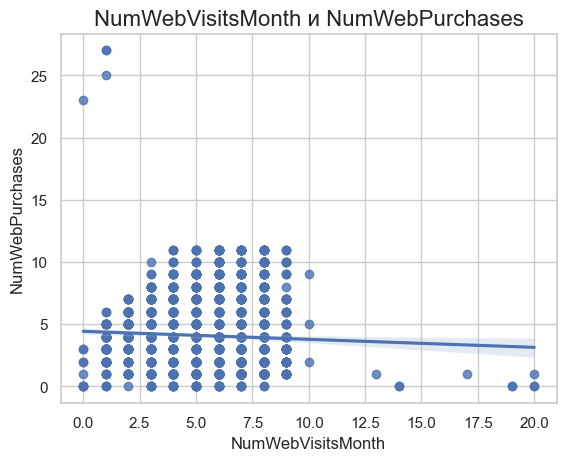

In [20]:
sns.regplot(data=df, x="NumWebVisitsMonth", y="NumWebPurchases")
plt.title("NumWebVisitsMonth и NumWebPurchases", size=16)
plt.show()

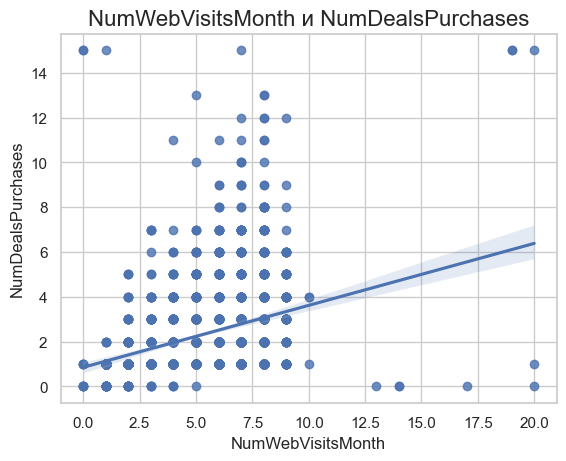

In [21]:
sns.regplot(data=df, x="NumWebVisitsMonth", y="NumDealsPurchases")
plt.title("NumWebVisitsMonth и NumDealsPurchases", size=16)
plt.show()

# 2. Статистический анализ

## 2.1. Какие факторы оказывают наибольшее влияние на покупки в заведениях?

Чтобы определить факторы, влияющие на покупки в заведениях (NumStorePurchases), проведем регрессионный анализ.

Посмотрим, с какими признаками коррелирует NumStorePurchases.

In [22]:
corr_df[corr_df["NumStorePurchases"].abs() >= 0.4]["NumStorePurchases"].sort_values(ascending=False)

NumStorePurchases      1.000000
TotalPurchases         0.820078
TotalMnt               0.675460
MntWines               0.642313
Income                 0.628075
NumCatalogPurchases    0.518788
NumWebPurchases        0.502227
MntMeatProducts        0.479983
MntFruits              0.463136
MntFishProducts        0.459997
MntSweetProducts       0.448673
NumWebVisitsMonth     -0.429857
Kidhome               -0.500192
Name: NumStorePurchases, dtype: float64

NumStorePurchases положительно коррелирует с:
1. Суммарные траты (TotalMnt) + траты по всем категориям.
2. Доход клиента (Income).
3. Покупки через каталог (NumCatalogPurchases).
4. Покупки через интернет-магазин (NumWebPurchases).

Отрицательные корреляции:
1. Посещение интернет-магазина за последний месяц (NumWebVisitsMonth).
2. Количество детей (Dependents).

Оценим, насколько данные переменные действительно оказывают влияние на NumStorePurchases.

Для начала проведем обработку данных. Поскольку у нас имеются как числовые, так и категориальные признаки, разделим и подготовим их для обучения.

In [23]:
# Создадим два набора данных: с числовыми и категориальными признаками
# Будем использовать их для обучения и других моделей в будущем.

# Категориальные переменные
categorical_data = df[["Education", "Marital_Status", "Complain", "Country"]]

# Количественные переменные (понадобятся, например, для стандартизации)
numerical_data = df.drop([*categorical_data.columns.to_list(), *campaign_cols, "ID"], axis=1)

In [24]:
categorical_data.head()

,Education,Marital_Status,Complain,Country
0,Graduation,Divorced,0,Spain
1,Graduation,Single,0,Canada
2,Graduation,Married,0,United States
3,Graduation,Together,0,Australia
4,Graduation,Single,0,Spain


In [25]:
numerical_data.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Dependents,Year_Customer,TotalMnt,TotalPurchases,TotalAcceptedCmp
0,1970,84835.0,0,0,0,189,104,379,111,189,218,1,4,4,6,1,0,2014,1190,15,1
1,1961,57091.0,0,0,0,464,5,64,7,0,37,1,7,3,7,5,0,2014,577,18,2
2,1958,67267.0,0,1,0,134,11,59,15,2,30,1,3,2,5,2,1,2014,251,11,0
3,1967,32474.0,1,1,0,10,0,1,0,0,0,1,1,0,2,7,2,2014,11,4,0
4,1989,21474.0,1,0,0,6,16,24,11,0,34,2,3,1,2,7,1,2014,91,8,2


Теперь подготовим данные непосредственно для обучения.

Очистим данные от следующих переменных:
- Целевая (NumStorePurchases)\
Ее мы будем предсказывать.
- Общее количество покупок (TotalPurchases)\
Поскольку она содержит информацию про целевую переменную, оставляя ее, мы столкнемся с проблемой утечки данных.
- Все данные по сумме покупок по категориям (MntWines, MntFruits и т.д.)\
Для общего понимания того, что влияет на целевую переменную, оставим только общую сумму покупок (TotalMnt).
- Информацию про количество детей (Kidhome/Teenhome)\
Также для общего понимания оставим только суммарное количество детей (Dependents).

Для преобразования категориальных признаков используем метод быстрого кодирования (one hot encoding).

In [26]:
# Целевая переменная
target = "NumStorePurchases"
y = df[target]

# Очистка и преобразование данных
df1 = numerical_data.drop([target, *mnt_cols, "TotalPurchases", "Kidhome", "Teenhome"], axis=1)  # числовые
df2 = pd.get_dummies(categorical_data, dtype=np.int8)  # категории

# Объединим получившиеся таблицы в одну
X = pd.concat([df1, df2], axis=1)
X.head()

,Year_Birth,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumWebVisitsMonth,Dependents,Year_Customer,TotalMnt,TotalAcceptedCmp,Complain,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Mexico,Country_South Africa,Country_Spain,Country_United States
0,1970,84835.0,0,1,4,4,1,0,2014,1190,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1961,57091.0,0,1,7,3,5,0,2014,577,2,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2,1958,67267.0,0,1,3,2,2,1,2014,251,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,1967,32474.0,0,1,1,0,7,2,2014,11,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
4,1989,21474.0,0,2,3,1,7,1,2014,91,2,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0


In [27]:
# Разделяем данные на обучающий и валидационный наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

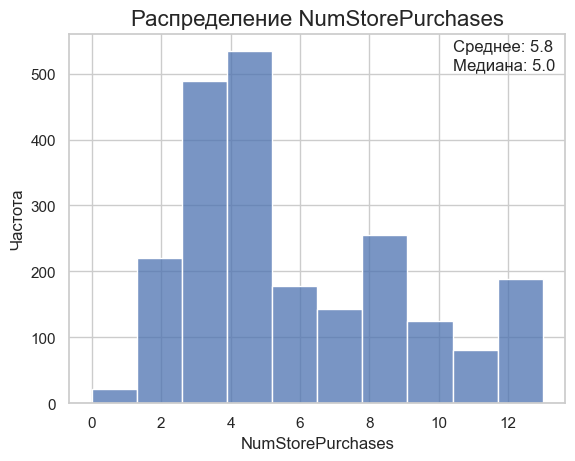

In [28]:
# Посмотрим на распределение NumStorePurchases

sns.histplot(df, x=target, bins=10)

plt.text(x=10.4, y= 507, s=f"Среднее: {df[target].mean().round(2)}\nМедиана: {df[target].median()}")

plt.title(f"Распределение {target}", size=16)
plt.ylabel("Частота")

plt.show()

В качестве модели будем использовать модель градиентного бустинга (GradientBoostingRegressor) из библиотеки scikit-learn.

Для подбора оптимальных параметров используем случайный поиск (RandomizedSearchCV).

In [29]:
param_dist = {
    "n_estimators": randint(100, 800),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(2, 6),
    "min_samples_leaf": randint(2, 20),
    "min_samples_split": randint(2, 30),
    "max_features": ["sqrt", "log2", None],
    "subsample": uniform(0.6, 0.4)
}

gbr = GradientBoostingRegressor(random_state=1)
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=1,
    refit=True
)

random_search.fit(X_train, y_train)
print("Лучшие параметры:", random_search.best_params_)

Лучшие параметры: {'learning_rate': np.float64(0.01451082343064134), 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 418, 'subsample': np.float64(0.9369945378033787)}


In [30]:
# Предсказания
train_preds = random_search.predict(X_train)  # предсказание на обучающих данных
test_preds = random_search.predict(X_test)  # предсказание на тренировочных данных

# Метрики модели регрессии
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_preds)).round(3)} R2: {np.round(r2_score(y_train, train_preds), 3)}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)).round(3)} R2: {np.round(r2_score(y_test, test_preds), 3)}")

Train RMSE: 1.184 R2: 0.87
Test RMSE: 1.726 R2: 0.695


Оценка модели на валидационной выборке:
- Переобучение: модель оказалась немного переобученной (не столь критично).
- RMSE ~ 1.7 -> модель в среднем ошибается на 30% от среднего значения целевой переменной.
- R2 ~ 0.7 -> модель объясняет 70% изменчивости данных.

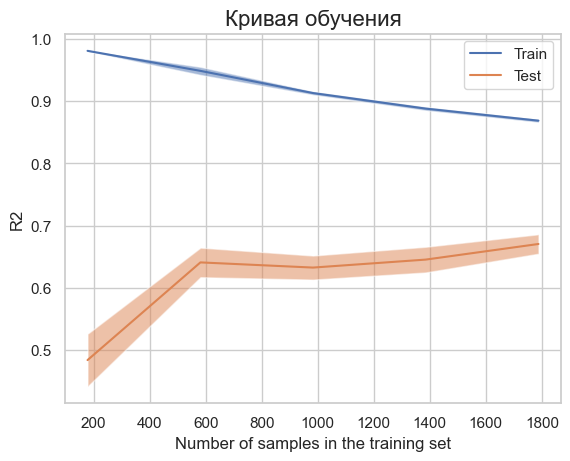

In [31]:
model = GradientBoostingRegressor(**random_search.best_params_, random_state=42)
curve = LearningCurveDisplay.from_estimator(model, X, y, scoring="r2")
plt.title("Кривая обучения", fontsize=16)
plt.show()

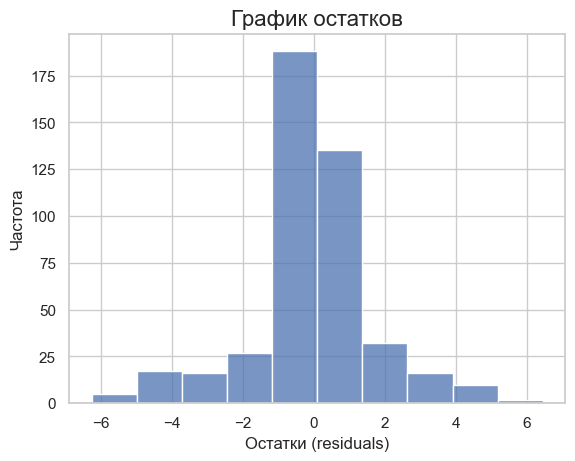

In [32]:
# Построим график остатков

sns.histplot(y_test - test_preds, bins=10)
plt.title("График остатков", size=16)
plt.xlabel("Остатки (residuals)")
plt.ylabel("Частота")
plt.show()

**Результат**: модель не дала самые лучшие предсказания, однако для наших целей этого будет более чем достаточно.

Оценим влияние признаков на предсказания модели.

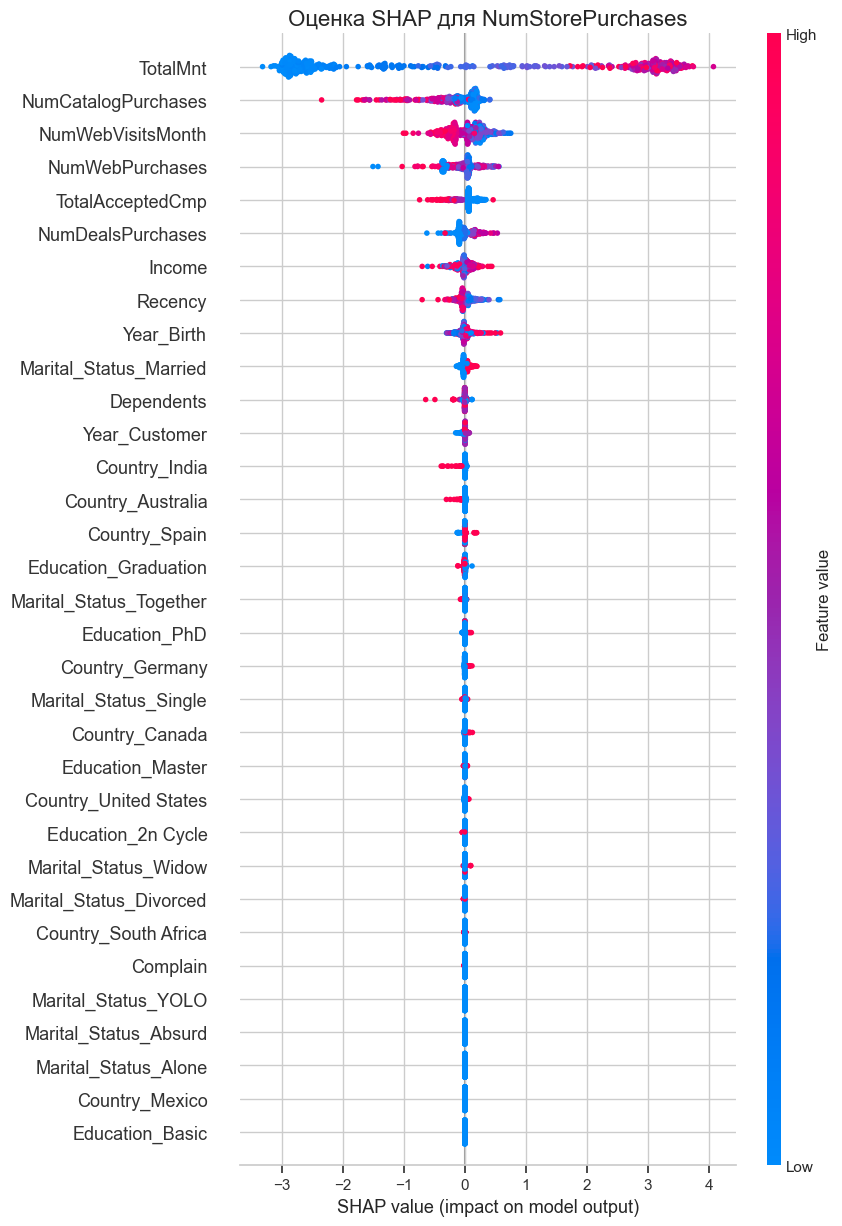

In [33]:
model.fit(X_train, y_train)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.title("Оценка SHAP для NumStorePurchases", size=16)
shap.plots.beeswarm(shap_values, max_display=None);

**Результат**: предполагаемые признаки действительно оказали влияние на прогноз модели.

Напрямую повлияли следующие признаки:
- Сумма покупок (TotalMnt)\
Очевидно, что чем больше клиент покупает, тем траты в среднем будут выше.\
Соответственно, данный канал пользуется большой популярностью у самых прибыльных клиентов.
- Доход (Income)\
Ранее мы замечати сильную корреляцию между количеством покупок и доходом клиентов. Данная зависимость оказалась слабее, чем ожидалось.

Обратно повлияли следующие признаки:
- Покупки через каталог и интернет-магазин (NumCatalongPurchases и NumWebPurchases)\
Скорее всего указывает на то, что у каждого клиента есть один предпочтительный канал покупок.
- Число посещений интернет-магазина за последний месяц (NumWebVisitsMonth)\
На основе корреляционно анализа мы выяснили, что у наиболее прибыльных клиентов не пользуются популярностью интернет-заказы.
- Число кампаний, в которых клиент принимал участие (TotalAcceptedCmp)\
Есть вероятность, что недавно проведенные кампании могли оказать обратный эффект на клиентов.

## 2.2. Лидируют ли США по общему числу покупок?

Посчитаем общее число покупок (TotalPurchases) для каждой страны. Дополнительно исследуем суммарную выручку.

In [34]:
# Сгруппируем данные по стране и посчитаем сумму для колонок TotalPurchases и TotalMnt

total_by_country = df.groupby(["Country"])[["TotalPurchases", "TotalMnt"]].agg("sum")
total_by_country

,TotalPurchases,TotalMnt
Country,,
Australia,2314,89763
Canada,4101,168532
Germany,1788,74913
India,2093,79420
Mexico,59,3122
South Africa,5102,210987
Spain,16037,660367
United States,1761,67882


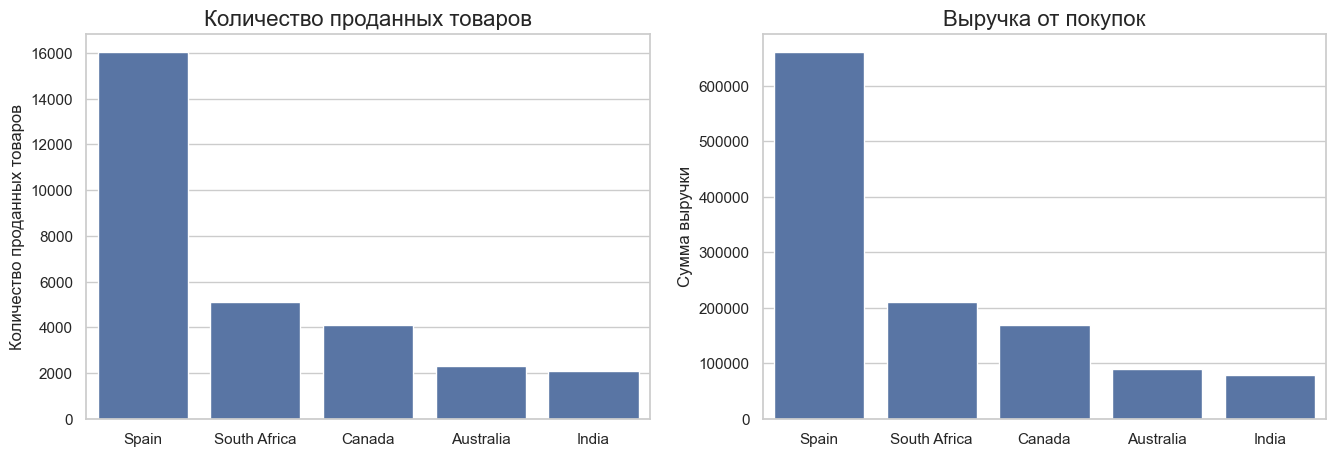

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# График, показывающий количество проданных товаров по стране (5 самых продаваемых)
sns.barplot(total_by_country.nlargest(5, "TotalPurchases")["TotalPurchases"], ax=ax[0])
ax[0].set_title("Количество проданных товаров", size=16)
ax[0].set_xlabel("")
ax[0].set_ylabel("Количество проданных товаров")

# График, показывающий суммарную выручку по стране (5 самых прибыльных)
sns.barplot(total_by_country.nlargest(5, "TotalMnt")["TotalMnt"], ax=ax[1])
ax[1].set_title("Выручка от покупок", size=16)
ax[1].set_xlabel("")
ax[1].set_ylabel("Сумма выручки")

plt.show()

Результат: США не входит ни в один топ-5 стран, откуда делаем вывод, что США **не лидирует** ни по какому признаку выше.

## 2.3. Верно ли, что клиенты, потратившие за последние два года на продукцию категории Gold сумму выше средней, совершают больше покупок в заведениях?

Сформулируем задачу: статистически значима ли разница в покупках в заведениях (NumStorePurchases) между клиентами, которые потратили на продукцию Gold (MntGoldProds) сумму ниже и выше средней.

Обозначим две гипотезы:\
**Нулевая гипотеза (H0)**: разницы между выборками нет.\
**Альтернативная гипотеза (H1)**: разница статистически значима.

In [36]:
# Уровень значимости тестов (альфа)
alpha = 0.05

Оценим отношение между переменными NumStorePurchases и MntGoldProds.

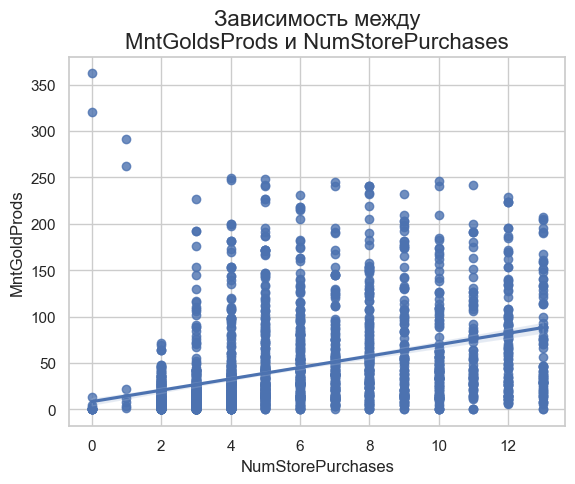

In [37]:
sns.regplot(df, x="NumStorePurchases", y="MntGoldProds")
plt.title("Зависимость между\nMntGoldsProds и NumStorePurchases", size=16)
plt.show()

Оценим распределение целевых переменных.

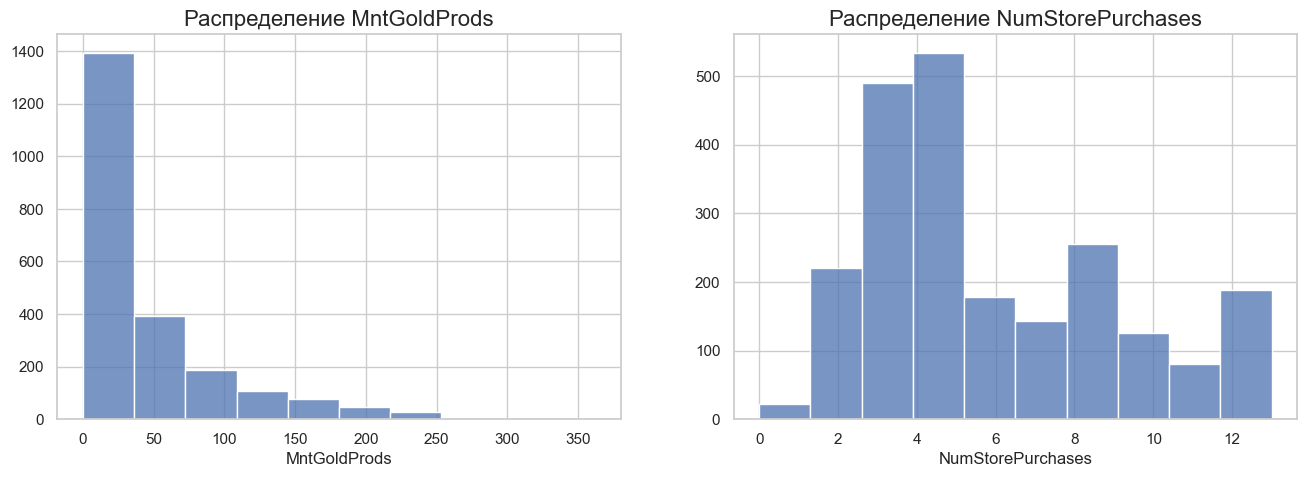

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма распределения MntGoldProds
sns.histplot(df, x="MntGoldProds", bins=10, ax=ax[0])
ax[0].set_title("Распределение MntGoldProds", size=16)
ax[0].set_ylabel("")

# Гистограмма распределения NumStorePurchases
sns.histplot(df, x="NumStorePurchases", bins=10, ax=ax[1])
ax[1].set_title("Распределение NumStorePurchases", size=16)
ax[1].set_ylabel("")

plt.show()

Обозначим две выборки:
1. NumStorePurchases клиентов, у которых MntGoldProds не превышает среднее значение.
2. NumStorePurchases клиентов, у которых MntGoldProds выше среднего.

In [39]:
avg = df["MntGoldProds"].mean()
below = df[df["MntGoldProds"] <= avg]["NumStorePurchases"]
above = df[df["MntGoldProds"] > avg]["NumStorePurchases"]

Для оценки схожести дисперсий используем тест Левена (подходит для скошенных данных).

In [40]:
p = stats.levene(below, above).pvalue
print(f"p-уровень значимости: {p}")
print(f"Выборки имеют схожие дисперсии: {p < alpha}")

p-уровень значимости: 7.52397645223565e-06
Выборки имеют схожие дисперсии: True


Для проверки статистической значимости используем стандартный t-тест для независимых выборок:
- размер обоих выборок достаточный, чтобы использовать t-тест даже для скошенных данных (работает ЦПТ).
- наши выборки никак не связаны между собой, т.к. они содержат информацию о разных клиентах.
- так как дисперсии схожи, используем классический t-тест.

In [41]:
p = stats.ttest_ind(below, above, equal_var=True).pvalue
print(f"p-уровень значимости: {p}")
print(f"Разница статистически значима: {p < alpha}")

p-уровень значимости: 2.7863196778074114e-91
Разница статистически значима: True


**Результат**: действительно, клиенты, потратившие на продукцию "Gold" сумму выше средней, имеют *больше* покупок в заведениях.

## 2.4. Существует ли взаимосвязь между клиентами категории Married & PhD и объемом трат на рыбную продукцию?

Создадим временную таблицу, в которой разделим клиентов на две категории:
- В браке (Married) и имеют степень докторскую степень (PhD): Yes
- Остальные: No

In [42]:
# Временная таблица, где создаем новую колонку is_MarriedPhD согласно условию выше.
# Из нее нам понадобятся только is_MarriedPhD и сумма трат MntFishProducts

temp = (
    df
    .assign(is_MarriedPhD=np.where(df["Marital_Status"] + df["Education"] == "MarriedPhD", "Yes", "No"))
    [["is_MarriedPhD", "MntFishProducts"]]
)
temp.head()

,is_MarriedPhD,MntFishProducts
0,No,111
1,No,7
2,No,15
3,No,0
4,No,11


Построим визуализацию, отображающую распределение MntFishProducts по двум получившимся категориям.

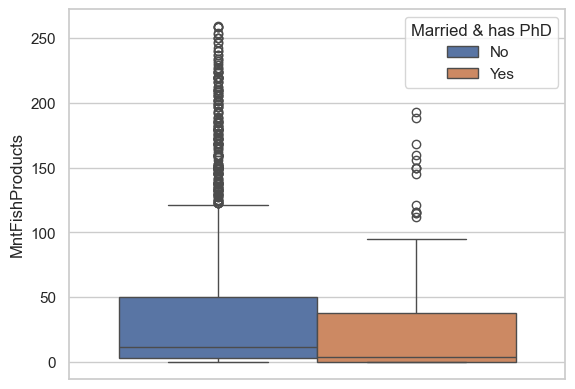

In [43]:
# Используем boxplot для визуализации различий

sns.boxplot(temp, y="MntFishProducts", hue="is_MarriedPhD")

plt.ylabel("MntFishProducts")

plt.legend(title="Married & has PhD")
plt.show()

Исследуем количество наблюдений, среднее и дисперсию по категориям

In [44]:
temp.groupby("is_MarriedPhD")["MntFishProducts"].agg(["count", "mean", "var"])

,count,mean,var
is_MarriedPhD,,,
No,2044,38.524462,3090.852558
Yes,192,27.015625,1763.826980


С первого взгляда имеются небольшие различия: клиенты группы Married & PhD MntFishProducts меньше, чем у остальных клиентов. Однако нам нужно понять, насколько данные различия статистически значимы.

Проведем t-тест Уэлча для независимых выборок.

In [45]:
# Выделим две выборки
s1 = temp[temp["is_MarriedPhD"] == "Yes"]["MntFishProducts"]  # Клиенты категории Married & PhD
s2 = temp[temp["is_MarriedPhD"] == "No"]["MntFishProducts"]  # Остальные

In [46]:
p = stats.ttest_ind(s1, s2, equal_var=False).pvalue
print(f"p-уровень значимости: {p}")
print(f"Разница статистически значима: {p < alpha}")

p-уровень значимости: 0.0005125246500068515
Разница статистически значима: True


**Результаты**: обнаруженная разница действительно *статистически значима*.\
Однако, как оказалось, на рыбную продукцию тратит больше другая категория клиентов, не Married & PhD.

## 2.5. Какие факторы в наибольшей степени влияют на траты на рыбную продукцию?

Как и в разделе 2.1, проведем регрессионный анализ и оценим влияние различных признаков на выручку с рыбной продукции (MntFishProducts).

Посмотрим, с какими переменными коррелирует MntFishProducts.

In [47]:
corr_df[corr_df["MntFishProducts"].abs() >= 0.4]["MntFishProducts"].sort_values(ascending=False)

MntFishProducts        1.000000
TotalMnt               0.642335
MntFruits              0.594415
MntSweetProducts       0.579490
MntMeatProducts        0.567813
NumCatalogPurchases    0.533969
Income                 0.518462
TotalPurchases         0.469309
NumStorePurchases      0.459997
MntGoldProds           0.422018
Dependents            -0.425148
NumWebVisitsMonth     -0.445729
Name: MntFishProducts, dtype: float64

Она положительно коррелирует со следующими переменными:
1. Траты по другим категориям (Mnt).
2. Покупки через каталог (NumCatalogPurchases) и в заведениях (NumStorePurchases).
3. Доход клиента (Income).
4. Общее количество купленных товаров (TotalPurchases).

Отрицательные корреляции:
1. Посещение интернет-магазина за последний месяц (NumWebVisitsMonth).
2. Количество детей (Dependents).

Подготовим данные для обучения.

In [48]:
# Используем данные numerical_data и categorical_data выше

# Целевая переменная
target = "MntFishProducts"
y = df[target]

# Очистка и преобразование данных
df1 = numerical_data.drop([target, *purchase_cols, "TotalMnt", "Kidhome", "Teenhome"], axis=1)
df2 = pd.get_dummies(categorical_data, dtype=np.int8)

# Объединим получившиеся таблицы в одну
X = pd.concat([df1, df2], axis=1)
X.head()

,Year_Birth,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntSweetProducts,MntGoldProds,NumWebVisitsMonth,Dependents,Year_Customer,TotalPurchases,TotalAcceptedCmp,Complain,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Country_Australia,Country_Canada,Country_Germany,Country_India,Country_Mexico,Country_South Africa,Country_Spain,Country_United States
0,1970,84835.0,0,189,104,379,189,218,1,0,2014,15,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1961,57091.0,0,464,5,64,0,37,5,0,2014,18,2,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2,1958,67267.0,0,134,11,59,2,30,2,1,2014,11,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,1967,32474.0,0,10,0,1,0,0,7,2,2014,4,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
4,1989,21474.0,0,6,16,24,0,34,7,1,2014,8,2,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0


In [49]:
# Разделяем данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

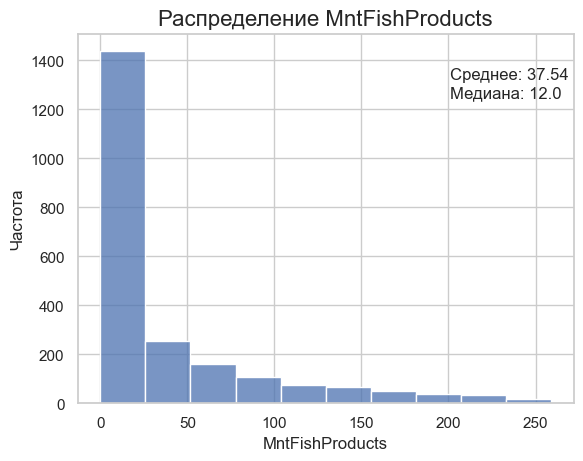

In [50]:
# Посмотрим на распределение MntFishProducts

sns.histplot(df, x=target, bins=10)
plt.text(x=201, y=1250, s=f"Среднее: {df[target].mean().round(2)}\nМедиана: {df[target].median()}")
plt.title(f"Распределение {target}", size=16)
plt.ylabel("Частота")
plt.show()

Так же, как и в разделе №2.1, подбираем параметры модели с помощью случайного поиска RandomizedSearchCV. 

In [51]:
param_dist = {
    "n_estimators": randint(100, 800),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(2, 6),
    "min_samples_leaf": randint(2, 20),
    "min_samples_split": randint(2, 30),
    "max_features": ["sqrt", "log2", None],
    "subsample": uniform(0.6, 0.4)
}

gbr = GradientBoostingRegressor(random_state=1)
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=1,
    refit=True
)

random_search.fit(X_train, y_train)
print("Лучшие параметры:", random_search.best_params_)

Лучшие параметры: {'learning_rate': np.float64(0.017412462786019708), 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 169, 'subsample': np.float64(0.7596613587646616)}


In [52]:
# Предсказания
train_preds = random_search.predict(X_train)  # предсказание на обучающих данных
test_preds = random_search.predict(X_test)  # предсказание на тренировочных данных

# Метрики модели регрессии
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_preds)).round(3)} R2: {np.round(r2_score(y_train, train_preds), 3)}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)).round(3)} R2: {np.round(r2_score(y_test, test_preds), 3)}")

Train RMSE: 30.572 R2: 0.684
Test RMSE: 38.678 R2: 0.516


Оценка модели:
- Обучение: модель недообучена.
- RMSE ~ 38 -> что выше среднего значения целевой переменной.
- R2 ~ 0.52 -> модель объясняет 52% изменчивости данных.

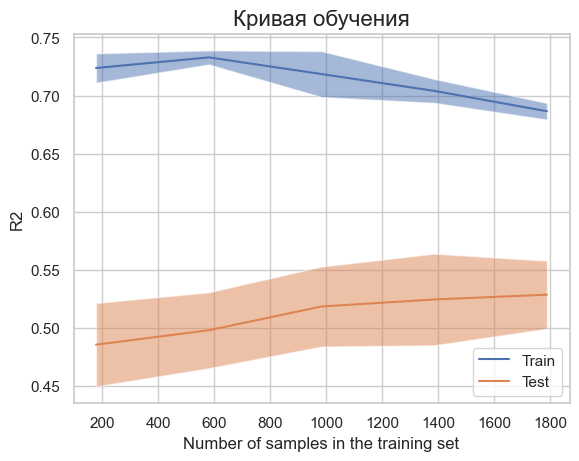

In [53]:
model = GradientBoostingRegressor(**random_search.best_params_, random_state=1)
curve = LearningCurveDisplay.from_estimator(model, X, y, scoring="r2")
plt.title("Кривая обучения", fontsize=16)
plt.show()

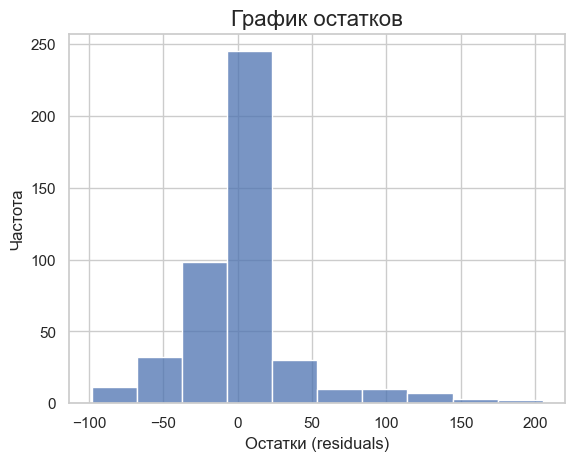

In [54]:
# Построим график остатков

sns.histplot(y_test - test_preds, bins=10)
plt.title("График остатков", size=16)
plt.xlabel("Остатки (residuals)")
plt.ylabel("Частота")
plt.show()

**Результат**: модель не дает точных предсказаний. Вероятнее всего это связано с тем, что целевая переменная (MntFishProducts) имеет случайных характер относительно других признаков.\
Несмотря на это, для оценки влияния признаков такой модели будет достаточно.

Оценим, какие признаки повлияли на предсказание модели.

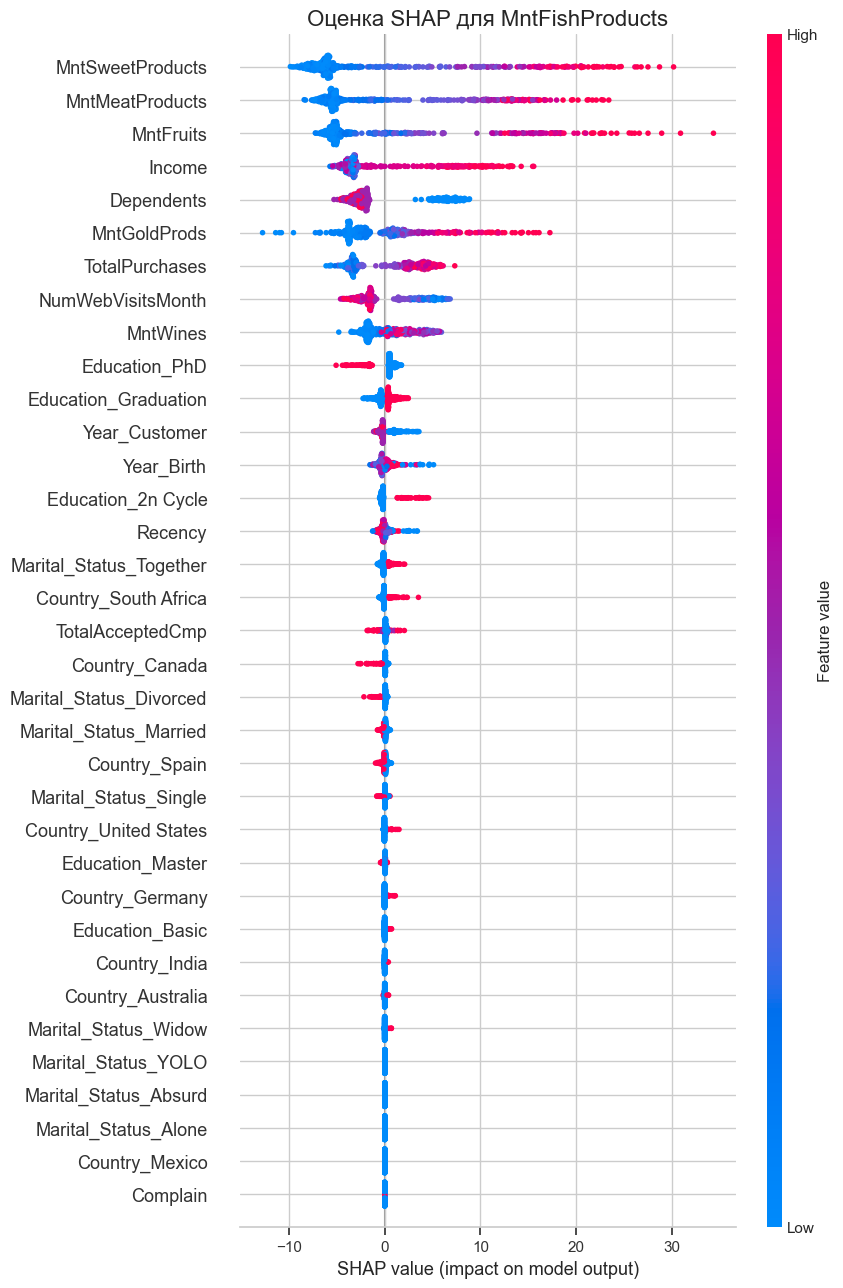

In [55]:
model.fit(X_train, y_train)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.title("Оценка SHAP для MntFishProducts", size=16)
shap.plots.beeswarm(shap_values, max_display=None);

**Результат**: следующие переменные оказали прямое влияние на MntFishProducts:
1. Траты по другим категориям, в особенности MntMeatProducts, MntSweetProducts, MntFruits\
Указывает на то, что клиенты активно приобретают и другие товары вместе с рыбной продукцией.
2. Доход (Income)\
Ранее мы обнаружили сильную корреляцию между тратами клиентов и их доходом. Данная зависимость оказалась значимой.
3. Общее количество покупок (TotalPurchases).

Обратный эффект на целевую переменную оказали признаки:
1. Количество посещений интернет-магазина за последний месяц (NumWebVisitsMonth)\
Опять же, мы уже выясняли, что у наиболее прибыльных клиентов не пользуются популярностью интернет-заказы, а Income оказал большой вклад в прогноз MntFishProducts.
2. Число детей у клиента (Dependents)\
Возможно, данный тренд наблюдается в следствие дорогостоимости рыбной продукции.
3. Наличие у клиента степени доктора философий (Education_PhD)\
Вклад в прогноз хоть и небольшой, но все же имеет смысл, так как в пунтке 2.4 мы обнаружили, что данная категория клиентов в среднем тратит на рыбную продукцию меньше.

Остальные признаки не оказали значимого влияния.

## 2.6. Зависит ли успех маркетинговой кампании от географического положения клиента?

Оценим успех каждой компании по всем странам. Визуализируем процент клиентов, принимавших участие в кампаниях.

In [56]:
campaign_map = {
    "AcceptedCmp1": "Campaign №1",
    "AcceptedCmp2": "Campaign №2",
    "AcceptedCmp3": "Campaign №3",
    "AcceptedCmp4": "Campaign №4",
    "AcceptedCmp5": "Campaign №5",
    "Response": "Most recent"
}

campaign_df = pd.melt(
    frame=df,
    id_vars="Country",
    value_vars=campaign_cols,
    var_name="Campaign",
    value_name="is_accepted"
)
campaign_df["Campaign"] = campaign_df["Campaign"].map(campaign_map)

temp = (campaign_df
    .groupby(["Campaign", "Country"])["is_accepted"]
    .apply(lambda x: np.round(np.mean(x) * 100, 2))
    .rename("Accepted (%)")
    .reset_index()
)
temp.head()

,Campaign,Country,Accepted (%)
0,Campaign №1,Australia,4.38
1,Campaign №1,Canada,6.72
2,Campaign №1,Germany,5.83
3,Campaign №1,India,4.76
4,Campaign №1,Mexico,0.00


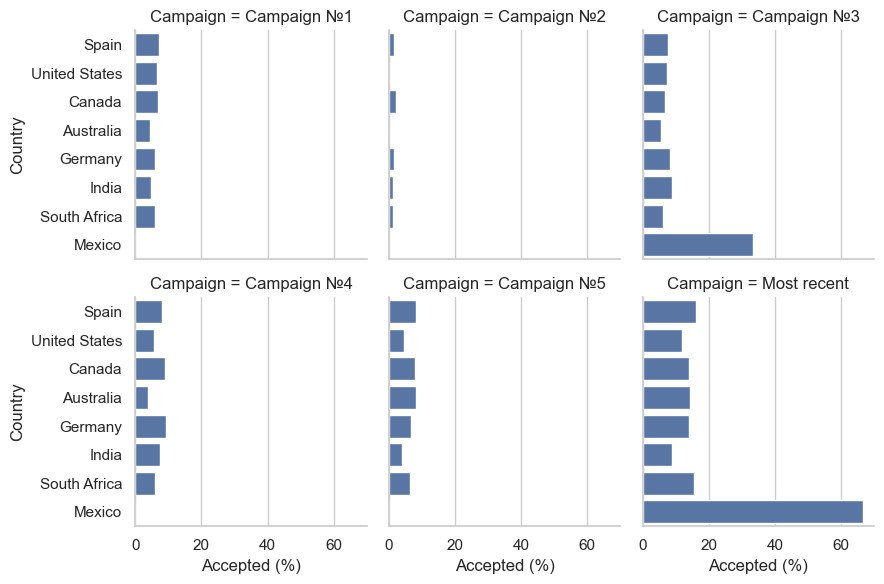

In [57]:
g = sns.FacetGrid(temp, col="Campaign", col_wrap=3, sharex=True)
g.map(sns.barplot, "Accepted (%)", "Country", order=country_abbreviations.values())
plt.show()

**Результат**:
- В целом процент клиентов, принимавших участие в кампаниях, низкий.
- Самой успешной кампанией оказалась крайняя (Most recent).
- Страной, в которой самый высокий процент участия в кампании, оказалсь Мексика (в 3-й и крайней кампаниях).

# 3. Кластерный анализ

В разделе №1 (разведочный анализ) мы обнаружили следующие зависимости:
- Уровень дохода (Income) коррелирует с суммой покупок (TotalMnt)
- Сумма покупок (TotalMnt) и количество детей (Dependents) имеют обратную корреляцию

Суть кластерного анализа заключается в том, чтобы сгруппировать данные по схожести, без заранее заданных категорий.
Будем использовать кластеризацию для сегментации клиентов по:
- Общей сумме трат (TotalMnt)
- Уровню дохода (Income)
- Количеству детей у клиента (Dependents)

In [58]:
cluster_df = df[["Income", "Dependents", "TotalMnt"]].copy()
cluster_df.head()

,Income,Dependents,TotalMnt
0,84835.0,0,1190
1,57091.0,0,577
2,67267.0,1,251
3,32474.0,2,11
4,21474.0,1,91


Для визуализации данных и кластеризации используем следующие методы:
- Метод главных компонент (PCA)
- Алгоритм DBSCAN

Соответственно, процесс предобработки данных включает только стандартизацию через StandardScaler.

In [59]:
# Предобработка данных
scaler = StandardScaler().fit(cluster_df)
X = pd.DataFrame(scaler.transform(cluster_df), columns=scaler.get_feature_names_out())
X.head()

,Income,Dependents,TotalMnt
0,1.536081,-1.264308,0.970556
1,0.240037,-1.264308,-0.048172
2,0.715402,0.065416,-0.589943
3,-0.909932,1.395139,-0.988792
4,-1.423790,0.065416,-0.855843


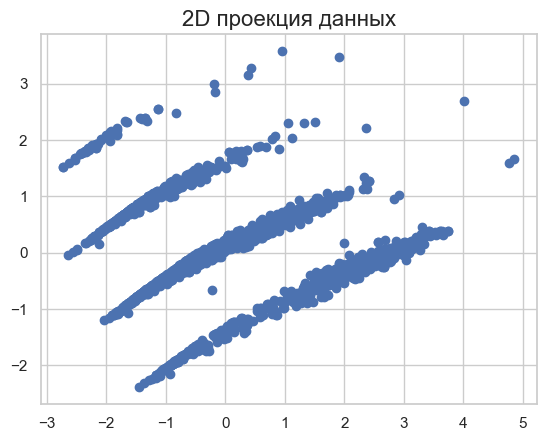

In [60]:
pca = PCA(n_components=2)
X_transformed = pca.fit_transform(X)

plt.scatter(*X_transformed.T)
plt.title("2D проекция данных", fontsize=16)
plt.show()

Видно, что четко выделяются 4 кластера.

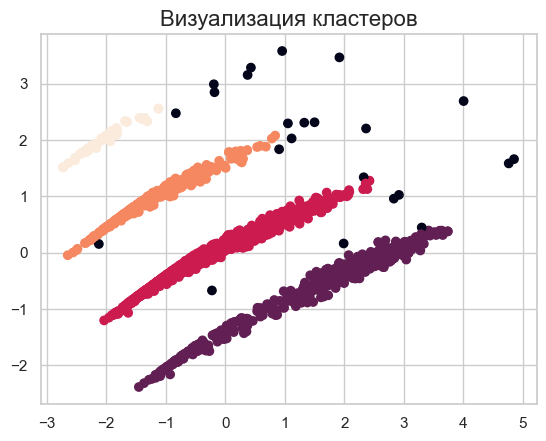

In [61]:
dbscan = DBSCAN().fit(X)

plt.scatter(*X_transformed.T, c=dbscan.labels_)
plt.title("Визуализация кластеров", fontsize=16)
plt.show()

Несколько точек остались необработанными, однако их отсутствие не мешает увидеть основные тренды.

In [62]:
cluster_df["cluster"] = dbscan.labels_
cluster_df = cluster_df[cluster_df["cluster"] != -1]

In [63]:
cluster_df.groupby("cluster").mean()

,Income,Dependents,TotalMnt
cluster,,,
0,64844.685420,0.0,1106.706815
1,46998.687333,1.0,471.013381
2,44051.496377,2.0,230.202899
3,43516.914894,3.0,140.404255


**Результат**: в конечном результате получилось 4 четко различимых кластера:
- Клиенты с высоким уровнем дохода тратят на покупки больше
- Многодетные клиенты тратят гораздо меньше чем те, у кого детей нет

Результат этого анализа можно использовать для разработки последующих рекламных кампаний, направив их различные группы клиентов.

# 4. Визуализация

## 4.1. Какая маркетинговая кампания оказалась наиболее успешной?

Посчитаем процент клиентов, участвовавших в каждой кампании.

In [64]:
temp = (
    campaign_df
    .groupby("Campaign")
    ["is_accepted"]
    .apply(lambda x: np.round(x.mean() * 100, 2))
    .rename("Accepted (%)")
    .sort_values(ascending=False)
)
temp

Campaign
Most recent    14.94
Campaign №4     7.47
Campaign №3     7.29
Campaign №5     7.25
Campaign №1     6.44
Campaign №2     1.34
Name: Accepted (%), dtype: float64

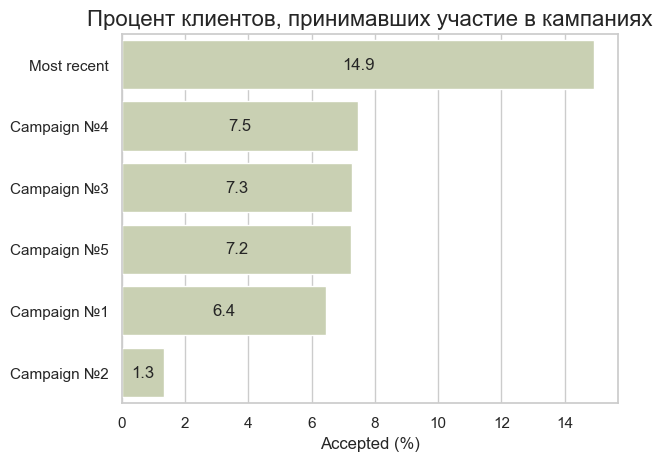

In [65]:
# Процент участия в кампаниях
ax = sns.barplot(temp, orient="h", color="#CCD5AE")

plt.title("Процент клиентов, принимавших участие в кампаниях", size=16)
plt.ylabel("")

# Обображение меток столбцов
for label in ax.containers: plt.bar_label(label, fmt=lambda x: f"{x:.1f}", label_type="center")
    
plt.show()

Результат: самой успешной оказалась **крайняя кампания** (Most recent).

## 4.2. Как выглядит портрет среднестатистического клиента iFood?

In [66]:
# Функция, которая группирует данные по одной колонке и возвращает 5 самых больших значений
count_df = lambda col: df.groupby(col)[col].count().nlargest(5)

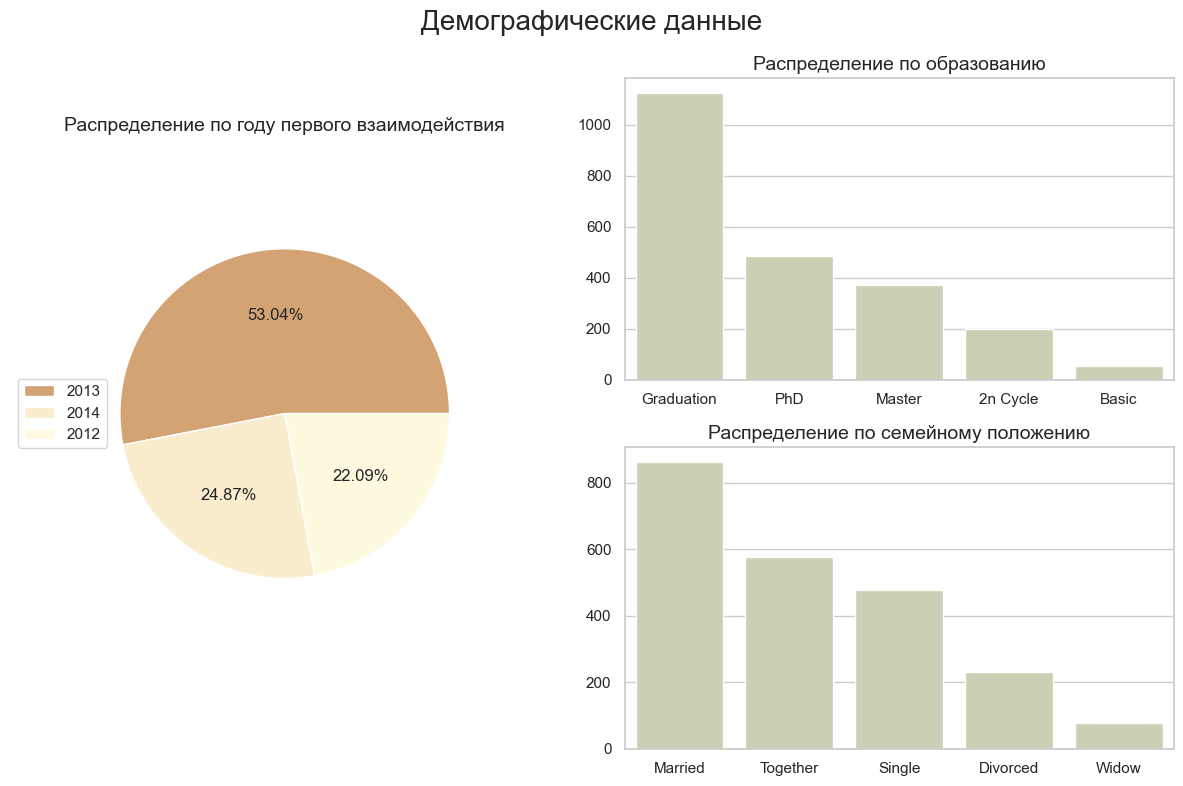

In [67]:
fig, axs = plt.subplot_mosaic([["left", "right_top"], ["left", "right_bottom"]], figsize=(12, 8))

fig.suptitle("Демографические данные", size=20)

# Год первого взаимодействия
data = count_df("Year_Customer").to_dict()

wedges, *_ = axs["left"].pie(
    data.values(),
    autopct=lambda x: f"{x:.2f}%",
    radius=0.75,
    colors=["#D4A373", "#FAEDCD", "#FEFAE0"]
)
axs["left"].set_title("Распределение по году первого взаимодействия", size=14)
axs["left"].legend(
    wedges, data.keys(),
    loc="center left"
)

# Образование
sns.barplot(count_df("Education"), ax=axs["right_top"], color="#CCD5AE")
axs["right_top"].set_title("Распределение по образованию", size=14)
axs["right_top"].set_xlabel("")
axs["right_top"].set_ylabel("")

# Семейное положение
sns.barplot(count_df("Marital_Status"), ax=axs["right_bottom"], color="#CCD5AE")
axs["right_bottom"].set_title("Распределение по семейному положению", size=14)
axs["right_bottom"].set_xlabel("")
axs["right_bottom"].set_ylabel("")

plt.tight_layout()
plt.show()

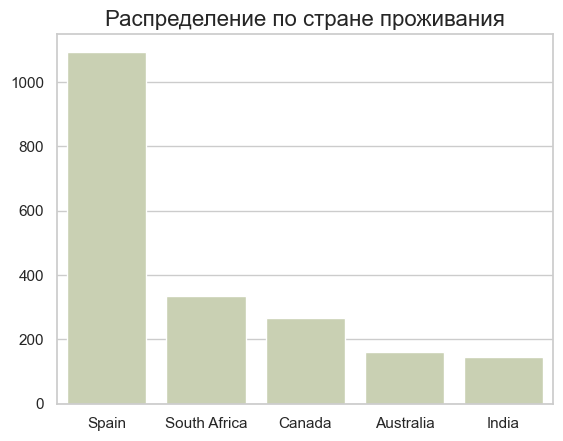

In [68]:
# Распределение по стране проживания
sns.barplot(count_df("Country"), color="#CCD5AE")
plt.title("Распределение по стране проживания", size=16)
plt.xlabel("")
plt.ylabel("")

plt.show()

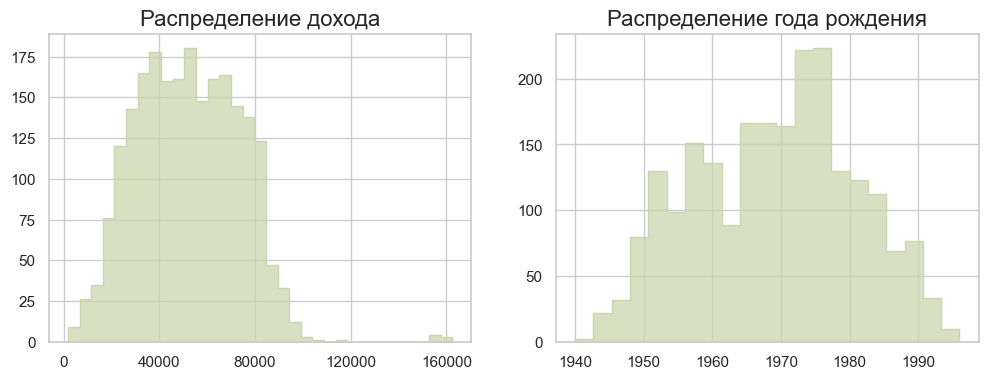

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Распределение дохода
sns.histplot(df["Income"], ax=ax[0], color="#CCD5AE", element="step")
ax[0].set_title("Распределение дохода", size=16)
ax[0].set_xlabel("")
ax[0].set_xticks(np.arange(0, 160001, 40000))
ax[0].set_ylabel("")

# Распределение года рождения
sns.histplot(df["Year_Birth"], ax=ax[1], color="#CCD5AE", element="step")
ax[1].set_title("Распределение года рождения", size=16)
ax[1].set_xlabel("")
ax[1].set_ylabel("")

plt.show()

In [70]:
# Статистика по доходу и году рождения
df[["Income", "Year_Birth"]].agg("mean").round()

Income        51953.0
Year_Birth     1969.0
dtype: float64

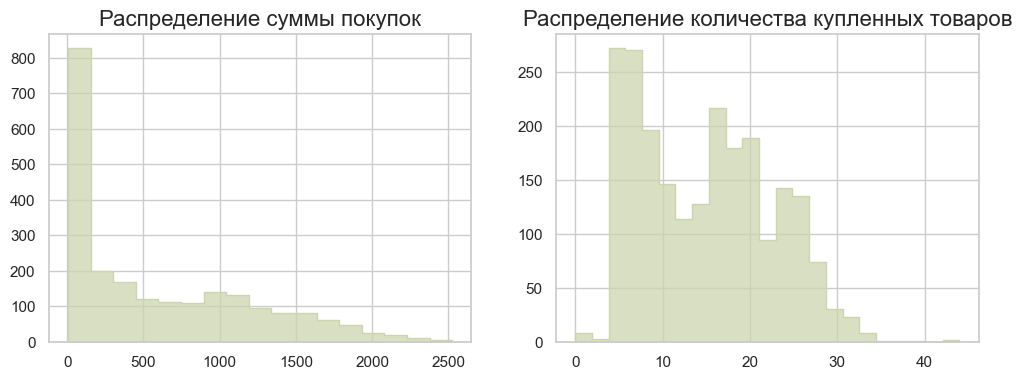

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Распределение суммы покупок
sns.histplot(df["TotalMnt"], ax=ax[0], color="#CCD5AE", element="step")
ax[0].set_title("Распределение суммы покупок", size=16)
ax[0].set_xlabel("")
ax[0].set_ylabel("")

# Распределение количества купленных товаров
sns.histplot(df["TotalPurchases"], ax=ax[1], color="#CCD5AE", element="step")
ax[1].set_title("Распределение количества купленных товаров", size=16)
ax[1].set_xlabel("")
ax[1].set_ylabel("")

plt.show()

In [72]:
# Статистика по сумме покупок и количеству купленных товаров
df[["TotalMnt", "TotalPurchases"]].agg("median")

TotalMnt          396.5
TotalPurchases     15.0
dtype: float64

Результат: среднестатистический клиент данной компании выглядит так:
- Год рождения: 1969
- Образование: высшее (graduation)
- Семейное положение: в браке
- Средний годовой доход (\$): 52 000
- Страна проживания: Испания
- Год первого взаимодействия: 2013
- Потратил $396.5 на покупки и приобрел 15 товаров

## 4.3. Какие продукты пользовались наибольшим спросом?

Рассчитаем, сколько в среднем один клиент тратил на продукцию по каждой категории.

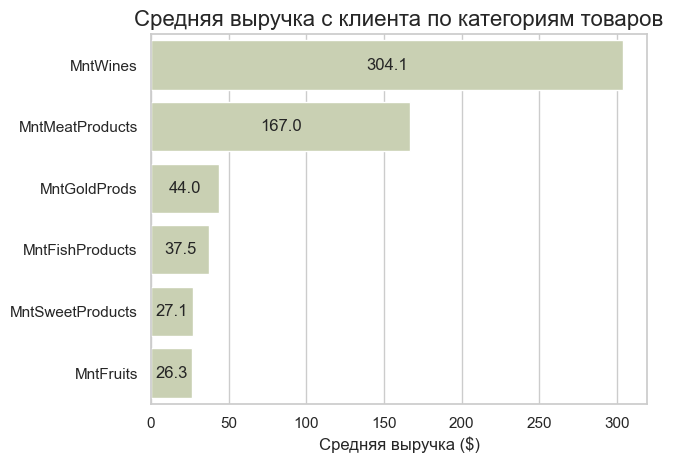

In [73]:
ax = sns.barplot(
    df[mnt_cols].mean(axis=0).sort_values(ascending=False),
    orient="h",
    color="#CCD5AE"
)

plt.title("Средняя выручка с клиента по категориям товаров", size=16)
plt.xlabel("Средняя выручка ($)")

# Отображение меток столбцов
for label in ax.containers: plt.bar_label(label, fmt=lambda x: f"{x:.1f}", label_type="center")

plt.show()

Результат: самой прибыльной оказалась продукция по следующим категориям:
- Вина (\$304.1).
- Мясная продукция (\$167.0).

## 4.4. Какие виды покупок оказались наименее популярными?

Оценим, сколько покупок в среднем совершил один клиент через каждый канал

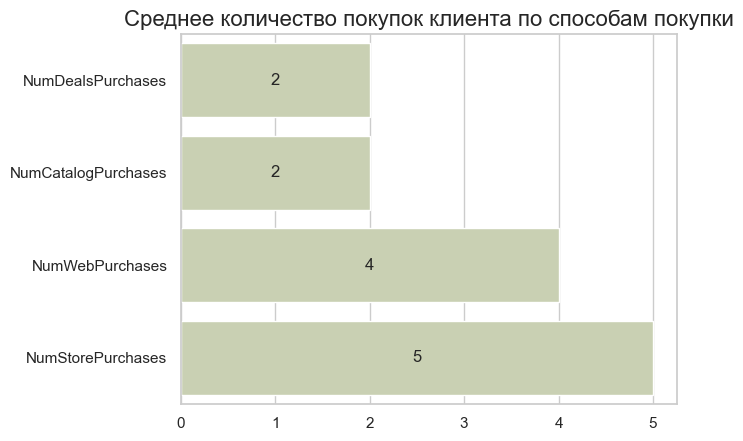

In [74]:
ax = sns.barplot(
    df[purchase_cols].median(axis=0).sort_values(),
    orient="h",
    color="#CCD5AE"
)

plt.title("Среднее количество покупок клиента по способам покупки", size=16)

# Отображение меток столбцов
for label in ax.containers: plt.bar_label(label, label_type="center")

plt.show()

# Результат

В ходе анализа мы можем сделать следующие выводы:
- Самой эффективной была модель крайней кампании; она оказалась особенно эффективной в Мексике\
**Предложение**: в будущем использовать модель этой кампании.
- Процент участия в кампаниях положительно коррелирует с доходом и отрицательно - с количеством детей\
**Предложение**: нацелить будущие кампании на две категории клиентов: первая - клиенты с высоким доходом / без детей и клиенты с низким доходом / с детьми.
- Самыми прибыльными оказались категории товаров "вино" и "мясная продукция"\
**Предложение**: фокусироваться на продаже наименее прибыльных товаров.
- Самые популярные способы покупок оказались покупки через интернет-магазин и непосредственно в заведении\
**Предложение**: нацелить будущие кампании на наиболее популярные каналы для привлечение больше новых клиентов.